In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from sklearn.utils import resample
import constant as const

In [2]:
import warnings
warnings.filterwarnings("ignore")

url = "http://127.0.0.1:80"
testcase = 'bestest_air'
testid = \
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)
print("done")

Using: cuda
done


In [3]:
testid = \
requests.post('{0}/testcases/{1}/select'.format(url,testcase)).json()['testid']
name = requests.get('{0}/name/{1}'.format(url, testid)).json()['payload']
print(name)

{'name': 'bestest_air'}


In [4]:
step = const.step

data = pd.read_csv(f'processed_uniform_low_step_5m_data.csv')
data_test = data
data.head()

T_zone = (data['zon_reaTRooAir_y'].values - 273.15) / 30.0
T_sup  = (data['fcu_oveTSup_u'].values - 273.15) / 40.0
fan  = data['fcu_oveFan_u'].values
T_out = (data['zon_weaSta_reaWeaTDryBul_y'].values - 273.15) / 10.0


pos_T_zone = T_zone[1:]
cur_T_zone = T_zone[:-1]
cur_T_sup = T_sup[:-1]
cur_fan = fan[:-1]
cur_T_out = T_out[:-1]

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

def data_split(Ns, Ne, x1, x2, x3, x4, x5):
    return (to_tensor(x1[Ns:Ne]).view(-1,1), to_tensor(x2[Ns:Ne]).view(-1,1),
            to_tensor(x3[Ns:Ne]).view(-1,1), to_tensor(x4[Ns:Ne]).view(-1,1), to_tensor(x5[Ns:Ne]).view(-1,1))


Ns_tr, Ne_tr = const.Ns_tr, const.Ne_tr  
Ns_t, Ne_t = const.Ns_t, const.Ne_t 

cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr, pos_T_zone_tr = data_split(Ns_tr, Ne_tr, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)
cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t, pos_T_zone_t = data_split(Ns_t, Ne_t, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)

X_tr = torch.cat((cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr), dim=1)
y_tr = pos_T_zone_tr.squeeze(-1)  


X_t = torch.cat((cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t), dim=1)
y_t = pos_T_zone_t.squeeze(-1)

ramp = const.ramp

class NN(nn.Module):
    def __init__(self, input_dim, hidden_dim=const.hidden_dim, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim),
                                 nn.ReLU(),
                                 nn.Linear(hidden_dim, output_dim)
                                 )
    def forward(self, x):
        return self.net(x)
    
nx = 1
nu = 2
no = 1


criterion = nn.MSELoss()


In [5]:
criterion = nn.MSELoss()
def train_nn(model, X, y, epochs=20, save=False, save_path='model_AL_NN.pth'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=const.lr, weight_decay=1e-3)

    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(X).squeeze(-1)
        loss = criterion(y, preds)
        loss.backward()
        optimizer.step()

    if save:
        torch.save(model.state_dict(), save_path)
    return model

def boot_NN_ls(X_tr, y_tr, num_bootstrap=10, epochs=20):
    model_ls = []
    bootstrap_data= []
    save_path_ls = []
    for i in range(num_bootstrap):
        X_boot, y_boot = resample(
            X_tr, y_tr,
            replace=True,
            n_samples=len(X_tr),
            random_state=i)
        bootstrap_data.append((X_boot, y_boot))
    for i, (X_i, y_i) in enumerate(bootstrap_data):
        torch.manual_seed(i*50)
        save_path_i = f'checkpoints/model_EMCM_bootstrap_{i}.pth'
        model_NN = NN(input_dim=nx+nu+no, hidden_dim=const.hidden_dim, output_dim=nx).to(device)
        if i > 0:
            model_NN.load_state_dict(torch.load(save_path_i))
        trained_NN = train_nn(model_NN, X_i, y_i, epochs=epochs)

        torch.save(trained_NN.state_dict(), save_path_i)
        model_ls.append(trained_NN)
        save_path_ls.append(save_path_i)
        
    return model_ls, save_path_ls

save_path = 'checkpoints/model_AL_EMCM_NN.pth'
save_path_ini='checkpoints/model_ini_AL_NN.pth'



In [6]:
def evaluate_NN(X_t, y_t, save_path):
    model = NN(input_dim=nx+nu+no, hidden_dim=const.hidden_dim, output_dim=nx).to(device)
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.to(device)
    model.eval()
    with torch.no_grad():
        observed_pred = model(X_t).squeeze(-1)
        rmse = torch.sqrt(torch.mean((observed_pred - y_t)**2))
    return rmse

In [8]:
from torch.func import vmap, jacrev, functional_call

def acqui_func(main_NN, model_ls, U_grid, X_0, X_out, plot=False):
    """
    Gradient-based Expected Model Change (BEMCM)
    main_NN  : main neural network (nn.Module)
    model_ls : committee models (list of nn.Module)
    U_grid   : tensor [N_points, 2] (normalized [0,1])
    X_0      : tensor [1, nx] (normalized)
    X_out    : tensor [1, nx] (normalized)
    """
    main_NN.to('cpu')
    main_NN.eval()
    for m in model_ls:
        m.to('cpu')
        m.eval()

    num_points = U_grid.shape[0]

    X_0_exp   = X_0.expand(num_points, -1)
    X_out_exp = X_out.expand(num_points, -1)
    Z_all = torch.cat((X_0_exp, U_grid, X_out_exp), dim=1)

    fx_all = main_NN(Z_all)

    params = dict(main_NN.named_parameters())
    def single_fwd(params, x):
        return functional_call(main_NN, params, x.unsqueeze(0)).squeeze(0)
    jacs = vmap(jacrev(single_fwd, argnums=0), in_dims=(None, 0))(params, Z_all)
    jac_norm = torch.sqrt(sum(v.flatten(1).pow(2).sum(1) for v in jacs.values()))

    with torch.no_grad():
        y_comms = torch.stack([m(Z_all) for m in model_ls])

    mean_diff = torch.abs(fx_all.unsqueeze(0) - y_comms).mean(0).squeeze(1)
    scores = jac_norm * mean_diff

    ind = torch.argmax(scores)
    U_optim = U_grid[ind]

    if plot:
        u1_vals = torch.unique(U_grid[:, 0]).cpu().numpy()
        u2_vals = torch.unique(U_grid[:, 1]).cpu().numpy()

        n1 = len(u1_vals)
        n2 = len(u2_vals)
        s_map = np.zeros((n2, n1))

        for k in range(len(scores)):
            i = np.where(u1_vals == U_grid[k, 0].cpu().numpy())[0][0]
            j = np.where(u2_vals == U_grid[k, 1].cpu().numpy())[0][0]
            s_map[j, i] = scores[k].item()

        plt.figure(figsize=(6,5))
        cp = plt.imshow(
            s_map,
            extent=[u1_vals.min(), u1_vals.max(),
                    u2_vals.min(), u2_vals.max()],
            origin="lower",
            aspect="auto"
        )

        print("Max score:", scores[ind].item())

        plt.colorbar(cp, label="Expected Model Change (Score)")
        plt.scatter(
            U_optim[0].cpu(),
            U_optim[1].cpu(),
            c="red",
            marker="x",
            s=100)
        plt.xlabel("u1 (Supply)")
        plt.ylabel("u2 (Airflow)")
        plt.title("BEMCM Acquisition Landscape")
        plt.show()
    return U_optim


class MPC:
    def __init__(self, main_NN, device='cpu'):
        self.device = device
        self.main_NN = main_NN
        self.main_NN.eval()

    def mpc_grid_search(self, u0_1, u0_2, X_0, X_out, model_ls, n_grid, plot=True):
        X_0_norm = torch.tensor(X_0, dtype=torch.float32, device=self.device).view(1, -1) / 30.0
        x_out_norm = torch.tensor(X_out, dtype=torch.float32, device=self.device).view(1, -1) / 10.0

        u1_vals = torch.linspace(max(u0_1-const.ramp, 0.3), min(u0_1+const.ramp, 1.0), n_grid)
        u2_vals = torch.linspace(max(u0_2-const.ramp, 0.0), min(u0_2+const.ramp, 1.0), n_grid)
        
        u1_vals = u1_vals[~torch.isclose(u1_vals, torch.tensor(u0_1))]
        u2_vals = u2_vals[~torch.isclose(u2_vals, torch.tensor(u0_2))]

        U_grid = torch.cartesian_prod(u1_vals, u2_vals)
        
        best_u = acqui_func(self.main_NN, model_ls, U_grid, X_0_norm, x_out_norm, plot=plot)
        
        return best_u, {
            'fcu_oveTSup_u': float(best_u[0] * 40 + 273.15),
            'fcu_oveTSup_activate': 1,
            'fcu_oveFan_u': float(best_u[1]),
            'fcu_oveFan_activate': 1
        }

In [9]:
y = requests.put('{0}/scenario/{1}'.format(url, testid), 
                 json={'time_period':'typical_heat_day',
                       'electricity_price':'dynamic'}).json()['payload']['time_period']
requests.put('{0}/step/{1}'.format(url, testid), json={'step':const.step*60})
start_time_days = y['time']/3600/24

In [10]:
counter = 0
u0_1 = 0.5
u0_2 = 0.5
u = {'fcu_oveTSup_u': u0_1 * 40 + 273.15,
    'fcu_oveTSup_activate': 1,
    'fcu_oveFan_u': u0_2,
    'fcu_oveFan_activate': 1}
print('Simulation time [elapsed days] = {:.2f}'.format((y['time']/3600/24 - start_time_days)))
y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']  
X_tr_new = X_tr
y_tr_new = y_tr

main_NN = NN(input_dim=nx+nu+no, hidden_dim=const.hidden_dim, output_dim=nx).to(device)
main_NN.load_state_dict(torch.load(save_path_ini, map_location=device))
main_NN = train_nn(main_NN, X_tr, y_tr, epochs=const.epoch_ini, save=True, save_path=save_path)

ls_rmse = [evaluate_NN(X_t, y_t, save_path=save_path)]

model_ls, save_boost_path = boot_NN_ls(X_tr, y_tr, num_bootstrap=const.N_bootstrap, epochs=const.epoch_ini)
n_grid = 10
print("Initial RMSE:", ls_rmse[-1])

Simulation time [elapsed days] = 0.00
Initial RMSE: tensor(0.2991, device='cuda:0')


In [11]:
evaluate_NN(X_t, y_t, save_path=save_path_ini)

tensor(1.2615, device='cuda:0')

In [12]:
number_of_data = 10
count_data = 1
while y:
    x0 = y['zon_reaTRooAir_y']-273.15
    x_out = (y['zon_weaSta_reaWeaTDryBul_y']-273.15)

    print('-------------------------------------------------------------------')
    print('Step counter =', counter)
    counter += 1
    mpc_controller = MPC(main_NN)
    best_u, u = mpc_controller.mpc_grid_search(u0_1=u0_1, u0_2=u0_2, X_0=x0, X_out=x_out, 
                                               model_ls=model_ls, n_grid=n_grid, plot=False)
    
    print('Selected control (normalized):', best_u.cpu().numpy())
    y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']  
    
    cur = to_tensor(x0).view(-1,1)/30.0
    T_sup_add = to_tensor((u['fcu_oveTSup_u']-273.15)/40.0).view(-1,1)
    fan_add = to_tensor(u['fcu_oveFan_u']).view(-1,1)
    pos_add = to_tensor(y['zon_reaTRooAir_y']-273.15).view(-1,1)/30.0
    T_out_add = to_tensor((y['zon_weaSta_reaWeaTDryBul_y']-273.15)/10.0).view(-1,1)

    X_tr_n, y_tr_n = torch.cat((cur, T_sup_add, fan_add, T_out_add), dim=1), pos_add.squeeze(-1)   
    X_tr_new, y_tr_new = torch.cat((X_tr_new, X_tr_n), dim=0), torch.cat((y_tr_new, y_tr_n), dim=0)
    
    if count_data == number_of_data:
        main_NN = train_nn(main_NN, X_tr_new, y_tr_new, epochs=const.epoch_onl, save=True, save_path=save_path)
        model_ls, save_boost_path = boot_NN_ls(X_tr_new, y_tr_new, num_bootstrap=const.N_bootstrap, epochs=const.epoch_onl)
        count_data = 0
    count_data += 1
    rmse = evaluate_NN(X_t, y_t, save_path=save_path)
    ls_rmse.append(rmse)

    u0_1 = (u['fcu_oveTSup_u'] - 273.15) / 40.0
    u0_2 = u['fcu_oveFan_u']

    if counter > const.num_count:
        break

-------------------------------------------------------------------
Step counter = 0
Selected control (normalized): [0.7 0.3]
-------------------------------------------------------------------
Step counter = 1
Selected control (normalized): [0.89999986 0.10000001]
-------------------------------------------------------------------
Step counter = 2
Selected control (normalized): [1. 0.]
-------------------------------------------------------------------
Step counter = 3
Selected control (normalized): [0.9777778  0.02222222]
-------------------------------------------------------------------
Step counter = 4
Selected control (normalized): [1. 0.]
-------------------------------------------------------------------
Step counter = 5
Selected control (normalized): [0.9777778  0.02222222]
-------------------------------------------------------------------
Step counter = 6
Selected control (normalized): [1. 0.]
-------------------------------------------------------------------
Step counter =

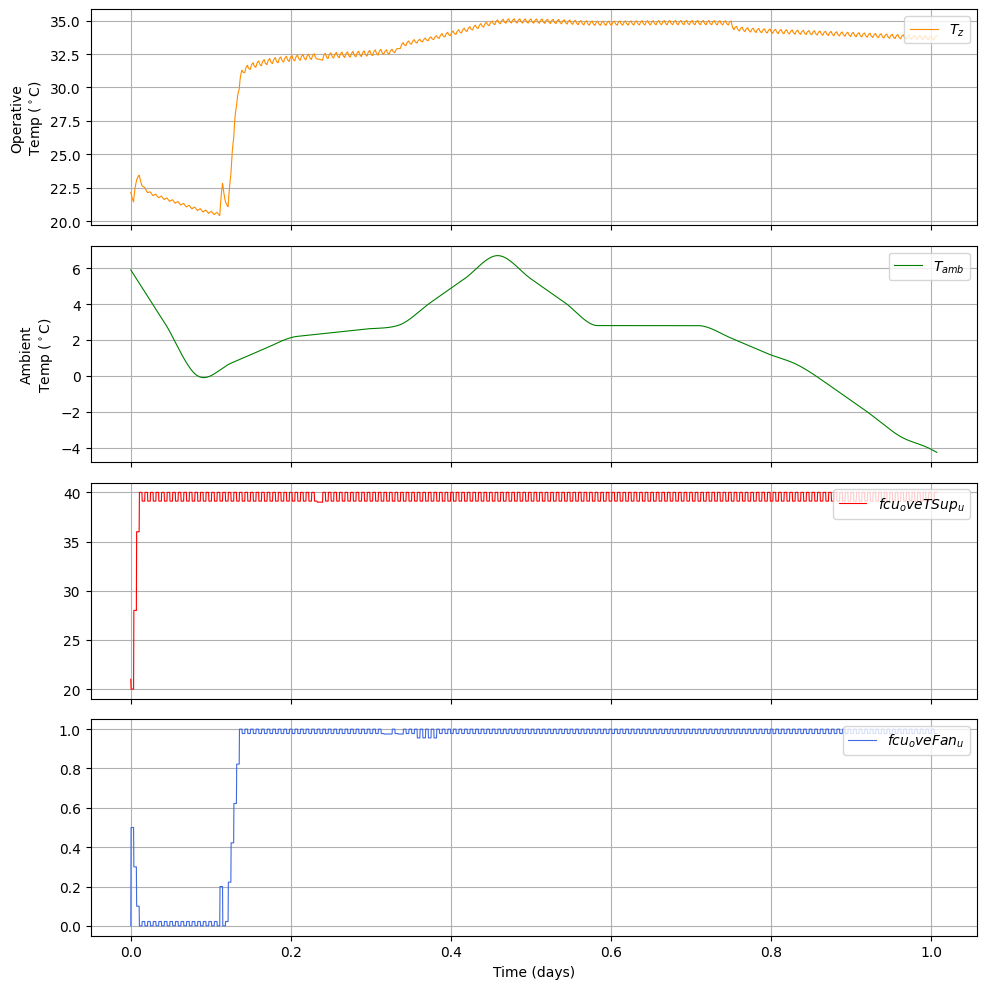

,zon_reaTRooAir_y,fcu_oveTSup_u,fcu_oveFan_u,zon_weaSta_reaWeaTDryBul_y,time
time,,,,,
3801600,295.310128,294.150000,0.000000,279.050000,0.000000
3801630,295.222125,293.150000,0.500000,279.025812,0.000347
3801660,295.117210,293.150000,0.500000,279.001625,0.000694
3801690,295.023884,293.150000,0.500000,278.977439,0.001042
3801720,294.940950,293.150000,0.500000,278.953254,0.001389
...,...,...,...,...,...
3888480,306.936901,313.149994,0.977778,268.916667,1.005556
3888510,306.954784,313.149994,0.977778,268.908333,1.005903
3888540,306.969307,313.149994,0.977778,268.900000,1.006250


In [13]:
def get_and_plot_results(testid, start_time, final_time):
    points = ['zon_reaTRooAir_y', 'fcu_oveTSup_u', 'fcu_oveFan_u', 'zon_weaSta_reaWeaTDryBul_y']
    args = {
        'point_names': points,
        'start_time': start_time, 
        'final_time': final_time
    }
    
    response = requests.put('{0}/results/{1}'.format(url, testid), json=args).json()
    
    if 'payload' not in response:
        print("Error: Could not retrieve data. Check if testid is still active.")
        return None
        
    df_res = pd.DataFrame(data=response['payload'])
    
    df_res = df_res.set_index('time')
    x_time = df_res.index / 3600. / 24.
    x_time = x_time - (start_time / 3600. / 24.)
    df_res['time'] = x_time
    

    plt.close('all')
    fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 10))
    
    axs[0].plot(x_time, df_res['zon_reaTRooAir_y'] - 273.15, color='darkorange', linewidth=0.8, label='$T_z$')
    axs[0].set_ylabel('Operative\nTemp ($^\circ$C)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True)

    axs[1].plot(x_time, df_res['zon_weaSta_reaWeaTDryBul_y'] - 273.15, color='green', linewidth=0.8, label='$T_{amb}$')
    axs[1].set_ylabel('Ambient\nTemp ($^\circ$C)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)

    axs[2].plot(x_time, df_res['fcu_oveTSup_u'] - 273.15, color='red', linewidth=0.8, label='$fcu_oveTSup_u$')
    axs[2].legend(loc='upper right')
    axs[2].grid(True)

    axs[3].plot(x_time, df_res['fcu_oveFan_u'], color='royalblue', linewidth=0.8, label='$fcu_oveFan_u$')
    axs[3].set_xlabel('Time (days)')
    axs[3].legend(loc='upper right')
    axs[3].grid(True)

    plt.tight_layout()
    plt.show()
    
    return df_res

start_in_seconds = start_time_days * 24 * 3600
final_in_seconds = start_in_seconds + (14 * 24 * 3600)

get_and_plot_results(testid=testid, start_time=start_in_seconds, final_time=final_in_seconds)

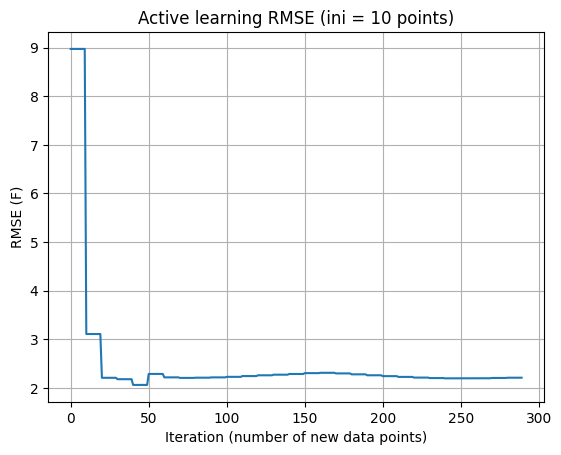

: 

In [ ]:
ls_rmse = [r.item()*30 for r in ls_rmse]    
plt.plot(ls_rmse)
plt.xlabel('Iteration (number of new data points)')
plt.grid()
plt.ylabel('RMSE (F)')
plt.title(f'Active learning RMSE (ini = {Ne_tr} points)')
plt.show()
import os
save_dir = 'results'
os.makedirs(save_dir, exist_ok=True)

df = pd.DataFrame(np.array(ls_rmse), columns=["RMSE_EMCM_NN"])

save_path = f"RMSE_EMCM_NN_ini{Ne_tr}_lr_{const.lr}_ramp_{const.ramp}.csv"                   
full_path = os.path.join(save_dir, save_path)               
df.to_csv(full_path, index=False)     